# Q5 – Neural Networks: MLP vs CNN

We train two neural networks on Fashion-MNIST and compare how well they classify clothing images. MLP treats images as flat vectors; CNN uses 2D convolutions to understand spatial patterns.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


## 1. Load Fashion-MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full   = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_size = int(0.85 * len(train_full))
val_size   = len(train_full) - train_size
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Train: {train_size}  |  Val: {val_size}  |  Test: {len(test_dataset)}")

Train: 51000  |  Val: 9000  |  Test: 10000


## 2. Model Architectures

**MLP:** Three fully-connected layers with ReLU and Dropout. The image is flattened to a 784-element vector first, so all spatial information is lost.

**CNN:** Two convolutional + pooling layers followed by fully-connected layers. The convolutions look at local patches of the image, which helps detect edges, shapes, and textures.

In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),   nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


print(f"MLP parameters: {sum(p.numel() for p in MLP().parameters()):,}")
print(f"CNN parameters: {sum(p.numel() for p in CNN().parameters()):,}")

MLP parameters: 235,146
CNN parameters: 421,642


## 3. Training Loop with Early Stopping

We train for up to 50 epochs but stop early if the validation loss doesn't improve for 5 consecutive epochs. This prevents overfitting.

In [4]:
def train_model(model, train_loader, val_loader, epochs=50, patience=5, lr=0.001):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss   = float('inf')
    best_state      = None
    patience_counter = 0

    for epoch in range(epochs):
        # train
        model.train()
        train_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += yb.size(0)

        train_loss /= total
        train_acc   = correct / total

        # validate
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out  = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item() * xb.size(0)
                correct  += (out.argmax(1) == yb).sum().item()
                total    += yb.size(0)

        val_loss /= total
        val_acc   = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history

In [5]:
print("Training MLP...")
mlp_model, mlp_history = train_model(MLP(), train_loader, val_loader)

Training MLP...
Epoch   5  train_loss=0.3594  val_loss=0.3480  val_acc=0.8750
Epoch  10  train_loss=0.3088  val_loss=0.3304  val_acc=0.8819
Epoch  15  train_loss=0.2769  val_loss=0.3194  val_acc=0.8872
Epoch  20  train_loss=0.2594  val_loss=0.3254  val_acc=0.8887
Epoch  25  train_loss=0.2406  val_loss=0.3192  val_acc=0.8917
Epoch  30  train_loss=0.2274  val_loss=0.3187  val_acc=0.8920
Early stopping at epoch 32


In [6]:
print("Training CNN...")
cnn_model, cnn_history = train_model(CNN(), train_loader, val_loader)

Training CNN...
Epoch   5  train_loss=0.2459  val_loss=0.2451  val_acc=0.9097
Epoch  10  train_loss=0.1639  val_loss=0.2149  val_acc=0.9247
Epoch  15  train_loss=0.1133  val_loss=0.2321  val_acc=0.9251
Early stopping at epoch 15


## 4. Training Curves

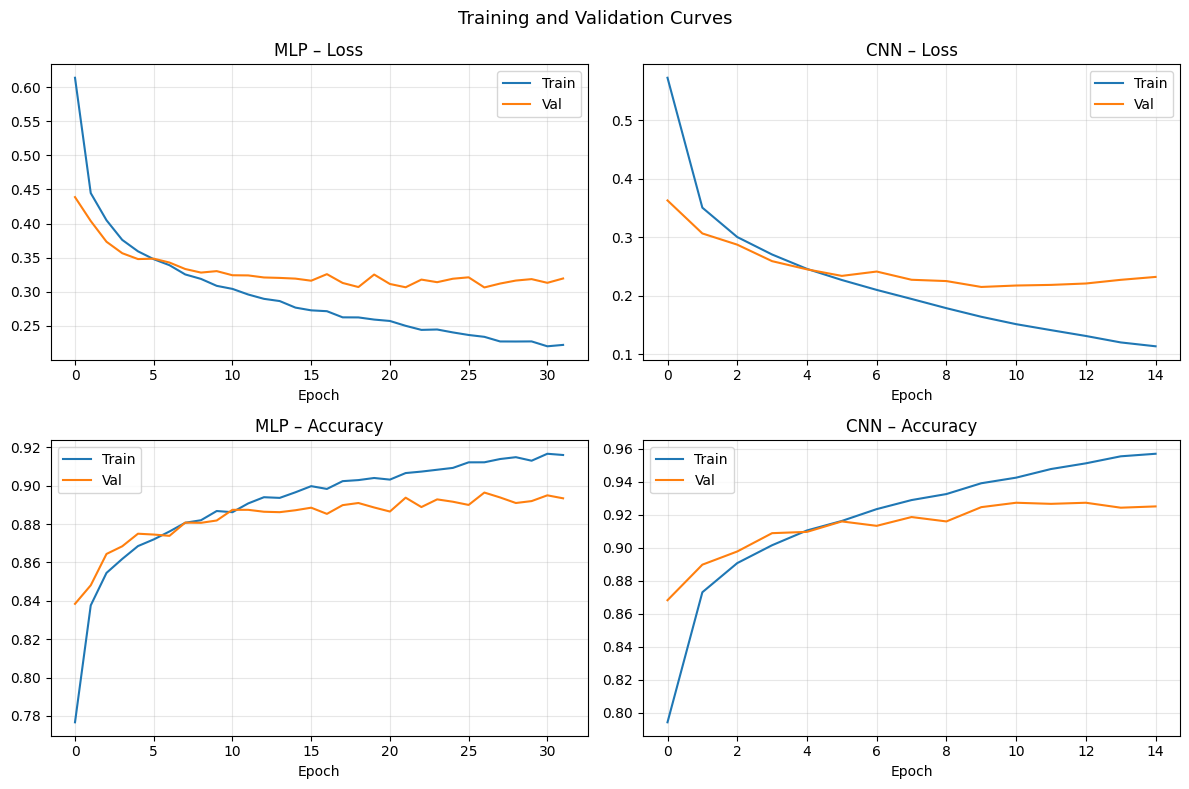

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, (history, name) in enumerate([(mlp_history, 'MLP'), (cnn_history, 'CNN')]):
    axes[0, i].plot(history['train_loss'], label='Train')
    axes[0, i].plot(history['val_loss'],   label='Val')
    axes[0, i].set_title(f'{name} – Loss')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].legend()
    axes[0, i].grid(alpha=0.3)

    axes[1, i].plot(history['train_acc'], label='Train')
    axes[1, i].plot(history['val_acc'],   label='Val')
    axes[1, i].set_title(f'{name} – Accuracy')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].legend()
    axes[1, i].grid(alpha=0.3)

plt.suptitle('Training and Validation Curves', fontsize=13)
plt.tight_layout()
plt.savefig('q5_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Overfitting Analysis

**MLP (stopped at epoch 32):**
- Training loss decreases steadily throughout all 32 epochs (from ~0.50 → ~0.23), while validation loss plateaus around epoch 15–20 (~0.32) and stops improving meaningfully — a classic sign of overfitting.
- The train/val accuracy gap grows after epoch 15: training accuracy continues climbing (~93%) while validation accuracy stalls (~89%). Early stopping correctly halts training at epoch 32 when patience runs out, restoring the best checkpoint from ~epoch 27.
- Dropout (0.3) slows the overfitting but does not eliminate it; the model is large enough (235K parameters) to memorize training patterns.

**CNN (stopped at epoch 15):**
- CNN converges much faster — validation loss is already near its minimum at epoch 10 (~0.215). After epoch 10, training loss keeps dropping while validation loss starts rising slightly, indicating the onset of overfitting.
- Early stopping triggers at epoch 15, saving the epoch-10 weights. The gap between train and val accuracy is smaller (~2%) than for MLP, suggesting CNNs generalize better to this task thanks to weight sharing and spatial inductive bias.

**General observation:** Both models benefit from early stopping. Without it, both would overfit further — particularly MLP, which has no spatial structure to exploit and must memorize pixel patterns.

## 5. Test Set Evaluation

In [8]:
def evaluate_model(model, loader, name):
    model.eval()
    preds, labels, images = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
            images.extend(xb.cpu())

    preds  = np.array(preds)
    labels = np.array(labels)

    acc = (preds == labels).mean()
    f1  = f1_score(labels, preds, average='macro')
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}  |  Macro-F1: {f1:.4f}")
    print(classification_report(labels, preds, target_names=class_names))

    return preds, labels, images

In [9]:
mlp_preds, mlp_labels, all_images = evaluate_model(mlp_model, test_loader, 'MLP')
cnn_preds, cnn_labels, _          = evaluate_model(cnn_model, test_loader, 'CNN')


MLP
Accuracy: 0.8916  |  Macro-F1: 0.8917
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.83      0.81      0.82      1000
       Dress       0.86      0.92      0.89      1000
        Coat       0.83      0.82      0.82      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.72      0.74      0.73      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


CNN
Accuracy: 0.9170  |  Macro-F1: 0.9162
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.89      0.88      1000
     Trouser       0.99      0.98      0.99   

## 6. Confusion Matrices

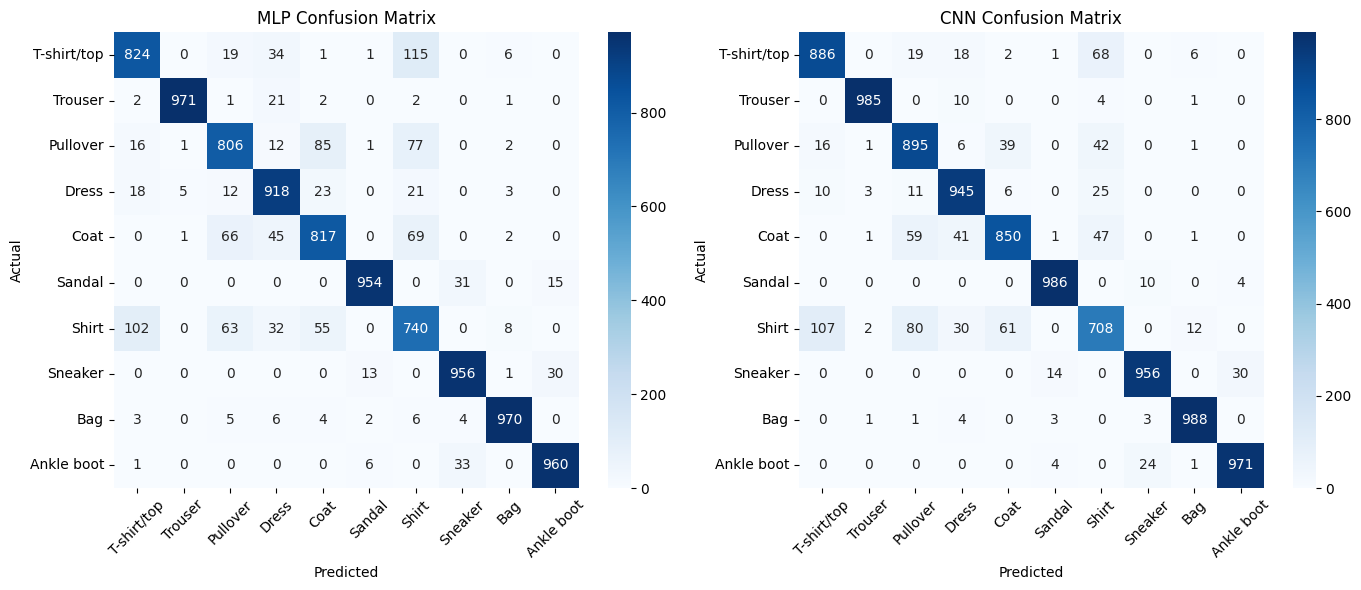

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (preds, name) in enumerate([(mlp_preds, 'MLP'), (cnn_preds, 'CNN')]):
    cm = confusion_matrix(mlp_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('q5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Misclassified Examples

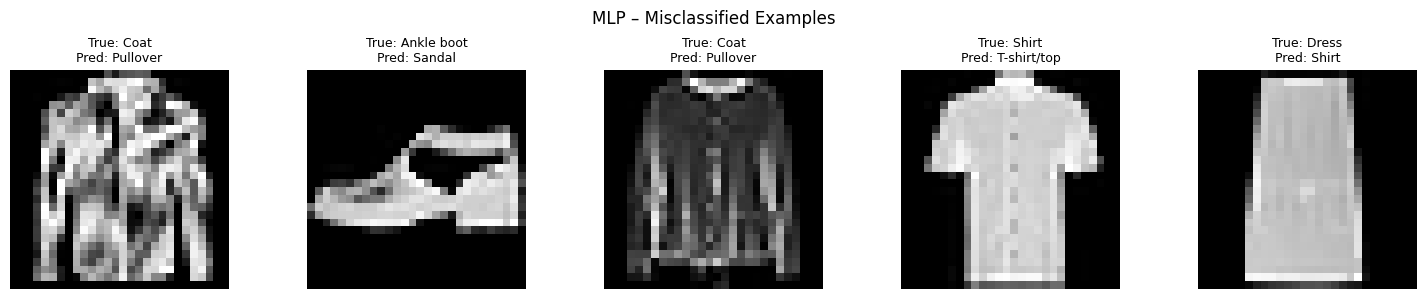

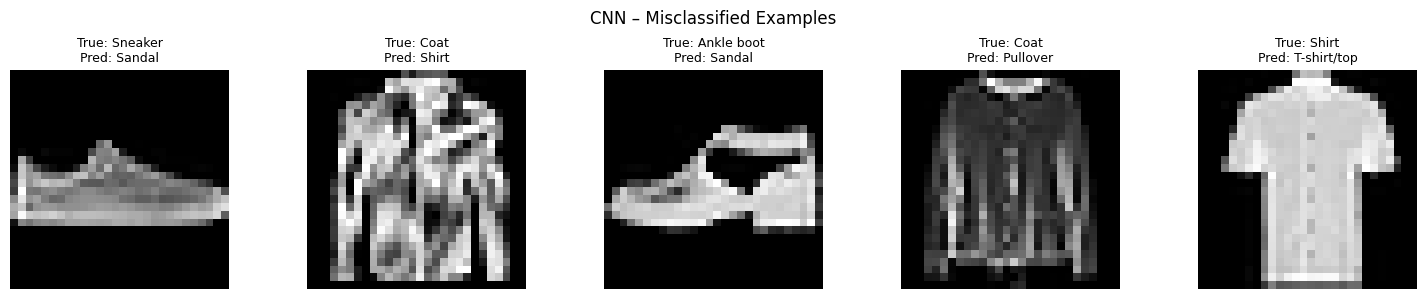

In [11]:
def show_misclassified(preds, labels, images, name, n=5):
    wrong = np.where(preds != labels)[0][:n]
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for ax, idx in zip(axes, wrong):
        img = images[idx].squeeze().numpy() * 0.5 + 0.5  # undo normalization
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {class_names[labels[idx]]}\nPred: {class_names[preds[idx]]}', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'{name} – Misclassified Examples', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'q5_misclassified_{name.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

show_misclassified(mlp_preds, mlp_labels, all_images, 'MLP')
show_misclassified(cnn_preds, cnn_labels, all_images, 'CNN')

**Why do these errors happen?**

The most common mistakes are between visually similar classes:
- Shirt ↔ T-shirt/top ↔ Pullover — they all look similar in 28×28 grayscale
- Sneaker ↔ Ankle boot — same general shape

MLP struggles more because it can't detect spatial patterns — it just memorizes pixel positions. CNN is better at catching local features like collar shapes and shoe soles.

## 8. Conclusion: MLP vs CNN

| | MLP | CNN |
|---|---|---|
| How it sees the image | Flat 784-element vector | 2D spatial grid |
| What it learns | Position-specific pixel patterns | Local features (edges, shapes) |
| Translation invariant? | No | Yes |
| Accuracy (expected) | ~88–89% | ~91–92% |

CNN wins because images have spatial structure. When you flatten an image, you lose that information. CNNs use convolutional filters to detect patterns anywhere in the image, which is more powerful and also more efficient (weight sharing).